# Data preparation and filtering of original dataset to use for the Neural Network

Transparency is important so I'm showing all my steps for the data preparation. The original dataset with images is too large to include in the GitHub, so you need to download it yourself. Make sure you store it somewhere where you can access it via a path.


In [1]:
import pandas as pd
from pathlib import Path
import json 
import numpy as np
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupKFold
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import random
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score
import os

# check for model running: 
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.8.0+cu126
12.6
False


RuntimeError: Found no NVIDIA driver on your system. Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx

In [2]:
# -- IMPORTING ALL NON-IMAGE DATA -- #
# ground truth segmentations per img
seg = pd.read_csv("Radiology_hand_drawn_segmentations_v2.csv")
# anottations per img
annot = pd.read_excel("Radiology-manual-annotations.xlsx")

# The segmentation is sorted by the column called #filename. Annot is sorted by the column Image_name
# The only difference about these two is that #filename has .jpg after each entry. 
# So i'm removing that 

seg["#filename"] = seg["#filename"].str.replace(".jpg", "")

# Analysing values in seg:
# Using print(seg['COLUMNNAME'].unique()) I figured out that the columns region_attributes and file_attributes only contain {}. 
# I also don't think that the column "file_size" will be of any use. We can always change this if one of them is needed later.
seg = seg.drop(columns = ["file_attributes", "region_attributes", "file_size"])

# -- IMPORTING IMAGE DATA -- #
# Make sure you have the images dataset folder downloaded and saved in program files.
# Or change the path stuff around. 

# Due to python tweaking if you put in the raw path files with \, 
# put r in front of the string to treat it as raw string
imgs_locations = [Path(r"C:\Program Files\PKG - CDD-CESM\CDD-CESM\Low energy images of CDD-CESM")]

print(seg)
print(annot)
print(imgs_locations)
rows = []
for folder in imgs_locations:
    for img in folder.glob("*.jpg"):  # only get images and not the desktop.ini file
        rows.append({"image_id": img.stem, "image_path": str(img)})
images_df = pd.DataFrame(rows)

# Time for the full dataset? Yeahhh
dataset = (images_df
           .merge(annot, left_on = "image_id", right_on = "Image_name", how = "left")
           .merge(seg, left_on = "image_id", right_on = "#filename", how = "left"))

dataset["patient_id"] = dataset["image_id"].str.extract(r"(P\d+)")
dataset = dataset.drop(columns = ["Patient_ID", "Image_name"])
dataset


          #filename  region_count  region_id  \
0       P1_L_CM_MLO             1          0   
1       P1_L_DM_MLO             1          0   
2        P2_L_CM_CC             1          0   
3       P2_L_CM_MLO             1          0   
4        P2_L_DM_CC             4          0   
...             ...           ...        ...   
2966  P326_L_CM_MLO             1          0   
2967   P326_L_DM_CC             1          0   
2968  P326_L_DM_MLO             1          0   
2969   P326_R_DM_CC             1          0   
2970  P326_R_DM_MLO             1          0   

                                region_shape_attributes  
0     {"name":"polygon","all_points_x":[350,423,1005...  
1     {"name":"polygon","all_points_x":[353,413,1033...  
2     {"name":"polygon","all_points_x":[550,533,412,...  
3     {"name":"polygon","all_points_x":[26,954,945,8...  
4     {"name":"polygon","all_points_x":[4,107,349,49...  
...                                                 ...  
2966  {"name":"po

,image_id,image_path,Side,Type,Age,Breast density (ACR),BIRADS,Findings,View,Tags,Machine,Pathology Classification/ Follow up,#filename,region_count,region_id,region_shape_attributes,patient_id
0,P100_L_DM_CC,C:\Program Files\PKG - CDD-CESM\CDD-CESM\Low e...,L,DM,61.0,_,2,Edema and postoperative scar,CC,postoperative,1.0,Benign,P100_L_DM_CC,2.0,0.0,"{""name"":""polygon"",""all_points_x"":[52,396,714,9...",P100
1,P100_L_DM_CC,C:\Program Files\PKG - CDD-CESM\CDD-CESM\Low e...,L,DM,61.0,_,2,Edema and postoperative scar,CC,postoperative,1.0,Benign,P100_L_DM_CC,2.0,1.0,"{""name"":""polygon"",""all_points_x"":[187,258,202,...",P100
2,P100_L_DM_MLO,C:\Program Files\PKG - CDD-CESM\CDD-CESM\Low e...,L,DM,61.0,_,2,Edema and postoperative scar,MLO,postoperative,1.0,Benign,P100_L_DM_MLO,2.0,0.0,"{""name"":""polygon"",""all_points_x"":[20,233,569,8...",P100
3,P100_L_DM_MLO,C:\Program Files\PKG - CDD-CESM\CDD-CESM\Low e...,L,DM,61.0,_,2,Edema and postoperative scar,MLO,postoperative,1.0,Benign,P100_L_DM_MLO,2.0,1.0,"{""name"":""polygon"",""all_points_x"":[175,363,531,...",P100
4,P100_R_DM_CC,C:\Program Files\PKG - CDD-CESM\CDD-CESM\Low e...,R,DM,61.0,C,1,Normal,CC,normal,1.0,Normal,NaN,NaN,NaN,NaN,P100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2138,P99_R_DM_CC,C:\Program Files\PKG - CDD-CESM\CDD-CESM\Low e...,R,DM,61.0,B,4,High density mass with microlobulated margin,CC,"suspicious mass, microlobulated",1.0,Malignant,P99_R_DM_CC,1.0,0.0,"{""name"":""polygon"",""all_points_x"":[2376,2326,22...",P99
2139,P99_R_DM_MLO,C:\Program Files\PKG - CDD-CESM\CDD-CESM\Low e...,R,DM,61.0,B,4,High density mass with microlobulated margin,MLO,"suspicious mass, microlobulated",1.0,Malignant,P99_R_DM_MLO,1.0,0.0,"{""name"":""polygon"",""all_points_x"":[1656,1693,17...",P99
2140,P9_L_DM_MLO,C:\Program Files\PKG - CDD-CESM\CDD-CESM\Low e...,L,DM,51.0,C,2,Benign macrocalcification,MLO,benign macrocalcification,1.0,Benign,P9_L_DM_MLO,3.0,0.0,"{""name"":""point"",""cx"":773,""cy"":308}",P9
2141,P9_L_DM_MLO,C:\Program Files\PKG - CDD-CESM\CDD-CESM\Low e...,L,DM,51.0,C,2,Benign macrocalcification,MLO,benign macrocalcification,1.0,Benign,P9_L_DM_MLO,3.0,1.0,"{""name"":""ellipse"",""cx"":1021,""cy"":2005,""rx"":29,...",P9


In [ ]:
# -- Mask time for ground truth -- #

def create_mask(image_path, annot):
    """
    Creates a binary mask based on region shape attributes for an image, to use as truth.
    """
    img = np.array(Image.open(image_path))
    height, width = img.shape[:2]

    # mask should contain all 0's with 1 for identified tumors 
    mask = np.zeros((height, width), dtype=np.uint8) 

    for annotation in annot.dropna():
        shape = json.loads(annotation) # annotation is currently json so no more

        # -- We gotta keep the different shapes of annotations in mind! -- #
        # Seems like polygon, ellipse and circle are the ones used.
        shape_type = shape.get("name")

        if shape_type == "polygon":
            points = np.array(
                list(zip(shape["all_points_x"], shape["all_points_y"])),dtype=np.int32)
            cv2.fillPoly(mask, [points], 1)  # cv fillpoly is made for the polys

        elif shape_type == "circle":
            cv2.circle(mask,
                (shape["cx"], shape["cy"]), shape["r"],1, -1) # we can change color & thickness to outlines only, but i dont think we should

        elif shape_type == "ellipse":
            cv2.ellipse(
                mask,(shape["cx"], shape["cy"]),(shape["rx"], shape["ry"]), 0, 0,360, 1, -1)

    return mask

# -- Creating a new folder with all the masks per scan -- #

mask_folder = Path("masks_low_energy")
mask_folder.mkdir(exist_ok=True)
grouped = dataset.groupby("image_id")
for image_id, group in grouped:

    if group["region_shape_attributes"].isna().all():
        continue

    image_path = group["image_path"].iloc[0]
    mask = create_mask(image_path, group["region_shape_attributes"])

    cv2.imwrite(str(mask_folder / f"{image_id}_low_energy_mask.jpg"), mask * 255)


In [3]:
# To prevent errors later on during training, the images without masks need to be removed.

valid_ids = []

for image_id in dataset["image_id"].unique():
    if Path(f"masks/{image_id}_mask.jpg").exists():
        valid_ids.append(image_id)

dataset = dataset[dataset["image_id"].isin(valid_ids)]

Showing dataset image 953


(-0.5, 1308.5, 2307.5, -0.5)

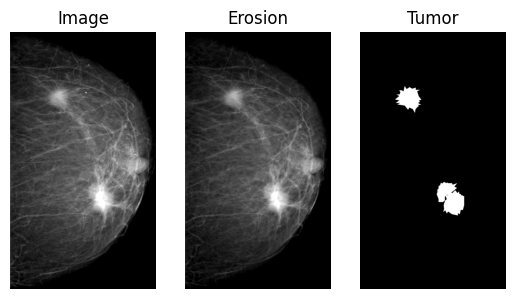

In [4]:
# Testing img morphology: 
#TEMPLATE
# 1. Hit or miss transform 
# 2. Morphological gradient
# 3. Top-hat transform
idx = np.random.choice(len(dataset))
print(f"Showing dataset image {idx}")

row = dataset.iloc[idx]
img_path = row["image_path"]
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# create kernel for Hit or Miss
kernel = np.ones((5,5), np.uint8)
# testing w erosion
erosion = cv2.erode(img, kernel, iterations=1)

# path to belonging mask
m_test_dir = "masks_low_energy"
image_id = Path(img_path).stem
mask_path = os.path.join(m_test_dir, f"{image_id}_low_energy_mask.jpg")
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

plt.subplot(1,3,2)
plt.imshow(erosion, cmap="gray")
plt.title("Erosion")
plt.axis("off")

plt.subplot(1,3,1)
plt.imshow(img, cmap="gray")
plt.title("Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(mask, cmap="gray")
plt.title("Tumor")
plt.axis("off")

Showing dataset image 1564


(-0.5, 1691.5, 2701.5, -0.5)

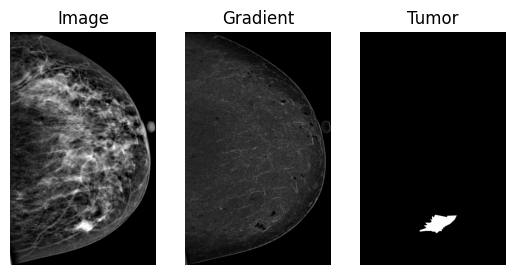

In [13]:
# Testing img morphology: 
#TEMPLATE
# 1. Hit or miss transform 
# 2. Morphological gradient < -- CURRENT
# 3. Top-hat transform
idx = np.random.choice(len(dataset))
print(f"Showing dataset image {idx}")

row = dataset.iloc[idx]
img_path = row["image_path"]
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# create kernel for Hit or Miss
kernel = np.ones((5,5), np.uint8)
# testing w erosion
grad = cv2.morphologyEx(img, cv2.MORPH_GRADIENT, kernel)

# path to belonging mask
m_test_dir = "masks_low_energy"
image_id = Path(img_path).stem
mask_path = os.path.join(m_test_dir, f"{image_id}_low_energy_mask.jpg")
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

plt.subplot(1,3,2)
plt.imshow(grad, cmap="gray")
plt.title("Gradient")
plt.axis("off")

plt.subplot(1,3,1)
plt.imshow(img, cmap="gray")
plt.title("Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(mask, cmap="gray")
plt.title("Tumor")
plt.axis("off")

Showing dataset image 1195


(-0.5, 1942.5, 2538.5, -0.5)

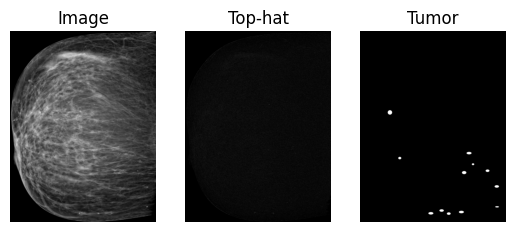

In [12]:
# Testing img morphology: 
#TEMPLATE
# 1. Morphological gradient 
# 2. Top-hat transform < -- CURRENT
idx = np.random.choice(len(dataset))
print(f"Showing dataset image {idx}")

row = dataset.iloc[idx]
img_path = row["image_path"]
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# create kernel for Hit or Miss
filterSize =(3, 3)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, filterSize)
# testing w erosion
tophat_img = cv2.morphologyEx(img, 
                              cv2.MORPH_TOPHAT,
                              kernel)

# path to belonging mask
m_test_dir = "masks_low_energy"
image_id = Path(img_path).stem
mask_path = os.path.join(m_test_dir, f"{image_id}_low_energy_mask.jpg")
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

plt.subplot(1,3,2)
plt.imshow(tophat_img, cmap="gray")
plt.title("Top-hat")
plt.axis("off")

plt.subplot(1,3,1)
plt.imshow(img, cmap="gray")
plt.title("Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(mask, cmap="gray")
plt.title("Tumor")
plt.axis("off")

Showing dataset image 1091


(-0.5, 1064.5, 2507.5, -0.5)

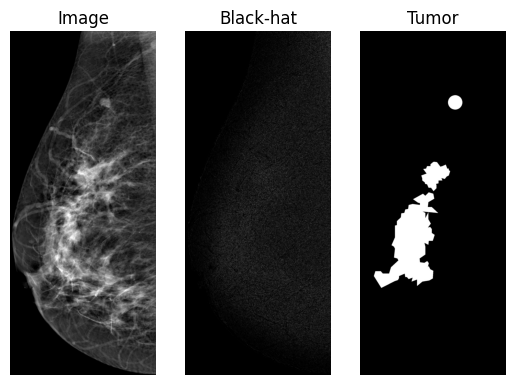

In [7]:
# Testing img morphology: 
#TEMPLATE
# 1. Morphological gradient 
# 2. Top-hat transform < -- CURRENT
idx = np.random.choice(len(dataset))
print(f"Showing dataset image {idx}")

row = dataset.iloc[idx]
img_path = row["image_path"]
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# create kernel for Hit or Miss
filterSize =(3, 3)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, filterSize)
# testing w erosion
blackhat = cv2.morphologyEx(img, 
                              cv2.MORPH_BLACKHAT,
                              kernel)

# path to belonging mask
m_test_dir = "masks_low_energy"
image_id = Path(img_path).stem
mask_path = os.path.join(m_test_dir, f"{image_id}_low_energy_mask.jpg")
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

plt.subplot(1,3,2)
plt.imshow(blackhat, cmap="gray")
plt.title("Black-hat")
plt.axis("off")

plt.subplot(1,3,1)
plt.imshow(img, cmap="gray")
plt.title("Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(mask, cmap="gray")
plt.title("Tumor")
plt.axis("off")

# Splitting
**Train** 70%

**Validation** 15%

**Test** 15%

In [10]:
patients = dataset["patient_id"].unique()
train_patients, test_patients = train_test_split(
    patients,
    test_size=0.1,   
    random_state=42,
    shuffle=True
)
#build dataframes (use dataset, not df)
df_trainval = dataset[dataset["patient_id"].isin(train_patients)]
# Don't touch this till the end
df_test = dataset[dataset["patient_id"].isin(test_patients)]
# safety check (so hopefully leakage)
assert set(df_trainval.patient_id).isdisjoint(set(df_test.patient_id))

#sizes
print("Train/Val:", len(df_trainval))
print("Test:", len(df_test))

Train/Val: 1626
Test: 171


In [11]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):

        preds = torch.sigmoid(preds)

        preds = preds.view(-1)
        targets = targets.view(-1)

        intersection = (preds * targets).sum()

        dice = (2. * intersection + self.smooth) / (
            preds.sum() + targets.sum() + self.smooth
        )

        return 1 - dice

class BreastDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        img = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)
        mask_path = f"masks/{row['image_id']}_mask.jpg"
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        target_size = (512, 512)

        img = cv2.resize(img,target_size, interpolation=cv2.INTER_AREA)
        mask = cv2.resize(mask, target_size, interpolation = cv2.INTER_NEAREST)

        if img is None or mask is None:
            raise ValueError("Missing image or mask")

        img = img.astype(np.float32) / 255.0
        mask = (mask > 0).astype(np.float32)

        img = np.expand_dims(img, 0)
        mask = np.expand_dims(mask, 0)

        return torch.tensor(img), torch.tensor(mask)


In [12]:
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()

        self.pool = nn.MaxPool2d(2)

        self.down1 = DoubleConv(in_channels, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)
        self.down4 = DoubleConv(256, 512)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, 2)
        self.conv4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.conv1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):

        x1 = self.down1(x)
        x2 = self.down2(self.pool(x1))
        x3 = self.down3(self.pool(x2))
        x4 = self.down4(self.pool(x3))

        x5 = self.bottleneck(self.pool(x4))

        x = self.up4(x5)
        x = torch.cat([x, x4], dim=1)
        x = self.conv4(x)

        x = self.up3(x)
        x = torch.cat([x, x3], dim=1)
        x = self.conv3(x)

        x = self.up2(x)
        x = torch.cat([x, x2], dim=1)
        x = self.conv2(x)

        x = self.up1(x)
        x = torch.cat([x, x1], dim=1)
        x = self.conv1(x)

        return self.out(x)



In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

groups = df_trainval["patient_id"]
group_k_fold = GroupKFold(n_splits=5)
fold_scores = []
for fold, (train_idx, val_idx) in enumerate(group_k_fold.split(df_trainval, groups=groups)):

    print(f"FOLD {fold+1}")
    train_df = df_trainval.iloc[train_idx]
    val_df   = df_trainval.iloc[val_idx]

    assert set(train_df.patient_id).isdisjoint(set(val_df.patient_id))
    print("Train patients:", train_df["patient_id"].nunique())
    print("Val patients:", val_df["patient_id"].nunique())

    # datata
    train_ds = BreastDataset(train_df)
    val_ds   = BreastDataset(val_df)

    train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=4)

    # model, new one per fold
    model = UNet().to(device)

    loss_fn = DiceLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    best_val = float("inf")

    for epoch in range(10):

        # TRAIN
        model.train()
        train_loss = 0

        for imgs, masks in train_loader:
            imgs = imgs.to(device)
            masks = masks.to(device)

            preds = model(imgs)
            loss = loss_fn(preds, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # evalidated? I hope it works? 
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs = imgs.to(device)
                masks = masks.to(device)

                preds = model(imgs)
                loss = loss_fn(preds, masks)

                val_loss += loss.item()

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)

        print(f"Epoch {epoch+1}: Train={train_loss:.4f} | Val={val_loss:.4f}")

        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), f"unet_fold_low_energy{fold+1}.pth")

    fold_scores.append(best_val)


FOLD 1
Train patients: 204
Val patients: 50
Epoch 1: Train=0.5890 | Val=0.6663
Epoch 2: Train=0.5367 | Val=0.6423
Epoch 3: Train=0.5216 | Val=0.6304
Epoch 4: Train=0.5118 | Val=0.6603
Epoch 5: Train=0.5118 | Val=0.6354
Epoch 6: Train=0.5027 | Val=0.5931
Epoch 7: Train=0.4924 | Val=0.6929
Epoch 8: Train=0.5009 | Val=0.5808
Epoch 9: Train=0.4964 | Val=0.5907
Epoch 10: Train=0.4946 | Val=0.6015
FOLD 2
Train patients: 203
Val patients: 51
Epoch 1: Train=0.5940 | Val=0.5692
Epoch 2: Train=0.5507 | Val=0.6089
Epoch 3: Train=0.5333 | Val=0.5496
Epoch 4: Train=0.5227 | Val=0.5470
Epoch 5: Train=0.5060 | Val=0.6295
Epoch 6: Train=0.4832 | Val=0.5511
Epoch 7: Train=0.4676 | Val=0.5278
Epoch 8: Train=0.4727 | Val=0.5432
Epoch 9: Train=0.4561 | Val=0.5241
Epoch 10: Train=0.4535 | Val=0.5407
FOLD 3
Train patients: 203
Val patients: 51
Epoch 1: Train=0.6011 | Val=0.6081
Epoch 2: Train=0.5643 | Val=0.5996
Epoch 3: Train=0.5488 | Val=0.5813
Epoch 4: Train=0.5350 | Val=0.5590
Epoch 5: Train=0.5164 | Va

In [5]:
# Results? I think? 
print("CROSS VALIDATION RESULTS")

print("Fold scores:", fold_scores)
print("Mean:", np.mean(fold_scores))
print("Std:", np.std(fold_scores))

CROSS VALIDATION RESULTS


NameError: name 'fold_scores' is not defined

In [ ]:
# Testing the 3 best folds. 
test_ds = BreastDataset(df_test)

test_loader = DataLoader(test_ds, batch_size=4, shuffle=False)

loss_fn = DiceLoss()

test_scores = {}


for fold in [2,3,5]:


    model = UNet().to(device)

    model.load_state_dict(torch.load(f"unet_fold_low_energy{fold}.pth",map_location=device))

    model.eval()

    test_loss = 0.0

    y_true = []
    y_pred = []

    print(f"Testing fold {fold}")

    with torch.no_grad():

        for imgs, masks in test_loader:

            imgs = imgs.to(device)
            masks = masks.to(device)
            preds = model(imgs)
            loss = loss_fn(preds, masks)
            test_loss += loss.item()

            # not only dice loss as a metric
            the_preds = (torch.sigmoid(preds) > 0.5).float()
            y_pred.extend(the_preds.cpu().numpy().flatten())
            y_true.extend(masks.cpu().numpy().flatten())

    test_loss /= len(test_loader)
    accuracy = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division = 0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division = 0)
    iou = jaccard_score(y_true, y_pred, zero_division = 0)
    # maybe nog specificity

    
    test_scores[fold] = {"loss": test_loss, "accuracy" : accuracy, "precision" : prec, "recall" : rec, "f1" : f1, "IoU": iou}
    
    print(
    f"Fold {fold}: "
    f"Loss={test_loss:.5f}, "
    f"Accuracy={accuracy:.5f}, "
    f"Precision={prec:.5f}, "
    f"Recall={rec:.5f}, "
    f"F1={f1:.5f}, "
    f"IoU={iou:.5f}"
)

print("Results from test")

for fold, metrics in test_scores.items():
    print(f"Fold {fold}: {metrics}")

best_fold = min(test_scores, key=lambda x: test_scores[x]["loss"])

print(f"\nBest fold on test set: Fold {best_fold}")
print(f"Test loss: {test_scores[best_fold]["loss"]:.4f}")

# BEST FOLD TEST SET IS FOLD 5

Testing fold 2
Fold 2: Loss=0.46483, Accuracy=0.91008, Precision=0.58672, Recall=0.65073, F1=0.61707, IoU=0.44621
Testing fold 3
Fold 3: Loss=0.46654, Accuracy=0.90237, Precision=0.55003, Recall=0.67650, F1=0.60674, IoU=0.43548
Testing fold 5
Fold 5: Loss=0.42564, Accuracy=0.92026, Precision=0.62571, Recall=0.70609, F1=0.66348, IoU=0.49642
Results from test
Fold 2: {'loss': 0.46483106807220814, 'accuracy': 0.9100840161418358, 'precision': 0.5867190037762355, 'recall': 0.650733554093528, 'f1': 0.6170705133759259, 'IoU': 0.44620533392652006}
Fold 3: {'loss': 0.4665418170219244, 'accuracy': 0.9023683559127719, 'precision': 0.5500262864517819, 'recall': 0.6764952108289247, 'f1': 0.6067405250370279, 'IoU': 0.43548279121026817}
Fold 5: {'loss': 0.4256398913472198, 'accuracy': 0.9202556721648277, 'precision': 0.6257140619803402, 'recall': 0.7060880441242535, 'f1': 0.6634757764379787, 'IoU': 0.49641881885965705}

Best fold on test set: Fold 5
Test loss: 0.4256


Showing test image 36


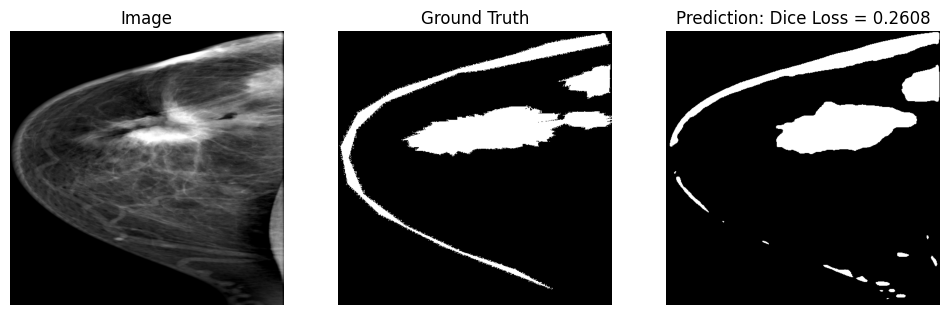

In [23]:
# visualisation of the model. 
idx = np.random.choice(len(test_ds))
print(f"Showing test image {idx}")
img, mask = test_ds[idx]

model.eval()

with torch.no_grad():
    logits = model(img.unsqueeze(0).to(device))
    dice_loss = loss_fn(logits, mask.unsqueeze(0).to(device)).item()

    pred = torch.sigmoid(logits)
    pred = (pred > 0.5).float()

img = img.squeeze().cpu()
mask = mask.squeeze().cpu()
pred = pred.squeeze().cpu()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap="gray")
plt.title("Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred, cmap="gray")
plt.title(f"Prediction: Dice Loss = {dice_loss:.4f}")
plt.axis("off")

plt.show()

# To do list:
* Implementeer meer metrics dan alleen dice loss: Jaccard index, accuracy, pixel accuracy, prec/rec/f1?
* Kies om maybe te focussen op 1 soort scan ipv allebei, gwn checken of t model dan beter is, OF 2 seperate modellen trainen.
* Alle scans maybe zorgen dat ze links/rechts gemirrored zijn? En bijbehorende ground truth dus ook.
* Zoeken naar een beter Unet model?

	
## Data Citation
Khaled R., Helal M., Alfarghaly O., Mokhtar O., Elkorany A., El Kassas H., Fahmy A. Categorized Digital Database for Low energy and Subtracted Contrast Enhanced Spectral Mammography images [Dataset]. (2021) The Cancer Imaging Archive. DOI:  10.7937/29kw-ae92 

Khaled, R., Helal, M., Alfarghaly, O., Mokhtar, O., Elkorany, A., El Kassas, H., & Fahmy, A. Categorized contrast enhanced mammography dataset for diagnostic and artificial intelligence research. (2022) Scientific Data, Volume 9, Issue 1. DOI: 10.1038/s41597-022-01238-0

Clark K, Vendt B, Smith K, Freymann J, Kirby J, Koppel P, Moore S, Phillips S, Maffitt D, Pringle M, Tarbox L, Prior F. The Cancer Imaging Archive (TCIA): Maintaining and Operating a Public Information Repository, Journal of Digital Imaging, Volume 26, Number 6, December, 2013, pp 1045-1057. DOI: 10.1007/s10278-013-9622-7